# chr3 demo pipeline for Hi-C and ChIA-PET tracks of GM12878 from 4DN.

Showcase of how to drive `3dgnome` from raw 4DN `.mcool` files:

1. **Hi-C** (GM12878 in situ Hi-C, hg38):
   - A/B compartments at 250 kb (cooltools `eigs_cis`)
   - TADs via insulation score at 25 kb to boundaries used as **segment breakpoints**
2. **ChIA-PET** (GM12878 CTCF ChIA-PET, hg38):
   - Loop calling with `cooltools.dots` on raw PET counts (unit weights)
   - Extract raw PET counts per loop from the matrix
   - Filter loops by CTCF JASPAR MA0139.1 motif at both anchors
   - Split into `clusters_3+.bedpe` (>=3 PETs) and `singletons_lessthan3.bedpe` (<3)
3. **Run 3dgnome** on a region using the generated files.

The notebook is meant to be run inside the `3dgnome-bio` conda env (see `environment.yml`).

## Used data:

- Hi-C: https://data.4dnucleome.org/files-processed/4DNFI46OLTQE/
- ChIA-PET: https://data.4dnucleome.org/files-processed/4DNFIMH3J7RW/

P.S.: You generally need Hi-C and ChIA-PET experiment for some single cell line to extract data. Try other cell lines!

## 0. Install dependencies

Conda env is intentionally bare (just Python + jupyter). All science deps live here so the notebook is self-contained. Comment the cell out after the first run.

In [59]:
%pip install --upgrade git+https://github.com/SFGLab/3dgnome-ng.git

  Cloning https://github.com/SFGLab/3dgnome-ng.git to /private/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/pip-req-build-p3zk7rkg
  Running command git clone --filter=blob:none --quiet https://github.com/SFGLab/3dgnome-ng.git /private/var/folders/ss/9hx8q7517rzf6x75cfny7ndc0000gp/T/pip-req-build-p3zk7rkg
  Resolved https://github.com/SFGLab/3dgnome-ng.git to commit d49614f4b2af35915f473228216fb361e3802f9d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [29]:
%pip install --upgrade \
    'numpy>=1.26,<2.0' 'pandas>=2.0,<2.3' \
    'cooler>=0.10,<0.11' 'cooltools>=0.7,<0.8' 'bioframe>=0.7,<0.8' \
    pysam scipy matplotlib seaborn requests tqdm pyranges

Note: you may need to restart the kernel to use updated packages.


In [1]:
import gzip
import os
import shutil
from pathlib import Path

import bioframe
import cooler
import cooltools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm

CWD = Path('.').resolve()
HIC_MCOOL = CWD / '4DNFI46OLTQE.mcool'
CHIAPET_MCOOL = CWD / '4DNFIMH3J7RW.mcool'
OUT = CWD / 'derived'
OUT.mkdir(exist_ok=True)
ASSEMBLY = 'hg38'

DEMO_CHRS = ['chr3']

assert HIC_MCOOL.exists() and CHIAPET_MCOOL.exists(), 'mcool files missing'
print('Hi-C:', HIC_MCOOL)
print('ChIA-PET:', CHIAPET_MCOOL)
print('out dir:', OUT)

Hi-C: /Users/nk2/Desktop/3dgnome-torch/playground/4DNFI46OLTQE.mcool
ChIA-PET: /Users/nk2/Desktop/3dgnome-torch/playground/4DNFIMH3J7RW.mcool
out dir: /Users/nk2/Desktop/3dgnome-torch/playground/derived


In [2]:
# Inspect what resolutions are stored in each mcool.
def list_resolutions(mcool):
    return sorted(
        int(r) for r in cooler.fileops.list_coolers(str(mcool))
        if '/resolutions/' in r
        for r in [r.rsplit('/', 1)[-1]]
    )


print('Hi-C resolutions:', list_resolutions(HIC_MCOOL))
print('ChIA-PET resolutions:', list_resolutions(CHIAPET_MCOOL))

Hi-C resolutions: [1000, 2000, 5000, 10000, 25000, 50000, 100000, 250000, 500000, 1000000, 2500000, 5000000, 10000000]
ChIA-PET resolutions: [1000, 2000, 5000, 10000, 25000, 50000, 100000, 250000, 500000, 1000000, 2500000, 5000000, 10000000]


In [3]:
# 4DN mcool files are usually shipped unbalanced. cooltools needs an ICE-balanced matrix (a `weight` column on the bins table) for both eigs_cis and insulation, so balance any resolution we plan to use, writing the weights back into the mcool in place.
# Cis-only balancing is fine for compartments + insulation and much faster than the full genome-wide variant.
from cooler import balance_cooler


def ensure_balanced(mcool_path, resolution, name='weight', **kwargs):
    uri = f'{mcool_path}::resolutions/{resolution}'
    clr = cooler.Cooler(uri)
    if name in clr.bins().columns:
        return clr
    print(f'Balancing {Path(mcool_path).name} @ {resolution // 1000} kb (one-time)')
    balance_cooler(
        clr,
        store=True,
        store_name=name,
        cis_only=True,
        **kwargs,
    )
    return cooler.Cooler(uri)

## 1. A/B compartments from Hi-C @ 250 kb

First eigenvector of the cis observed/expected matrix, phased by GC content so sign matches the conventional "A = active, gene-rich, high GC" convention.

In [4]:
COMP_RES = 250_000
clr_hic_comp = ensure_balanced(HIC_MCOOL, COMP_RES)

# View frame = chromosome arms (centromere-split) intersected with DEMO_CHRS.
chromsizes = clr_hic_comp.chromsizes
cens = bioframe.fetch_centromeres(ASSEMBLY)
view = bioframe.make_chromarms(chromsizes, cens)
if DEMO_CHRS is not None:
    view = view[view['chrom'].isin(DEMO_CHRS)].reset_index(drop=True)
view.head()

,chrom,start,end,name
0,chr3,0,90900000,chr3_p
1,chr3,90900000,198295559,chr3_q


In [5]:
# GC content track for phasing the eigenvector. pysam needs either plain fasta or bgzip,
# UCSC ships regular gzip, so we decompress once to .fa and let pysam build the .fai index on it.

fa_gz = OUT / f'{ASSEMBLY}.fa.gz'
fa_path = OUT / f'{ASSEMBLY}.fa'
if not fa_path.exists():
    if not fa_gz.exists():
        url = 'https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz'
        print(f'Downloading {url} (one-time, ~900 MB compressed)')
        with requests.get(url, stream=True) as r:
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0)) or None
            with open(fa_gz, 'wb') as fh, tqdm(
                total=total, unit='B', unit_scale=True, unit_divisor=1024,
                desc='hg38.fa.gz') as bar:
                for chunk in r.iter_content(chunk_size=2 ** 20):
                    fh.write(chunk)
                    bar.update(len(chunk))

    print(f'Decompressing {fa_gz.name} to {fa_path.name} (~3 GB)')

    with gzip.open(fa_gz, 'rb') as src, open(fa_path, 'wb') as dst, tqdm(
        unit='B', unit_scale=True, unit_divisor=1024, desc='hg38.fa') as bar:
        while True:
            chunk = src.read(2 ** 20)
            if not chunk:
                break
            dst.write(chunk)
            bar.update(len(chunk))

    fa_gz.unlink()

bins = clr_hic_comp.bins()[:]
bins = bioframe.frac_gc(bins, bioframe.load_fasta(str(fa_path)))
bins.head()

/opt/anaconda3/envs/3dgnome-bio/lib/python3.11/site-packages/bioframe/extras.py:316: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("chrom", sort=False)[["start", "end"]].apply(_each)


,chrom,start,end,KR,VC,VC_SQRT,weight,GC
0,chr1,0,250000,0.030997,0.004246,0.058918,NaN,0.443708
1,chr1,250000,500000,0.022027,0.002222,0.042619,NaN,0.418652
2,chr1,500000,750000,0.089810,0.051847,0.205872,NaN,0.433950
3,chr1,750000,1000000,0.652467,0.563153,0.678499,0.010011,0.513908
4,chr1,1000000,1250000,0.773576,0.755429,0.785838,0.010043,0.617632


In [6]:
# Now we run the eigenvector phasing
cis_eigs = cooltools.eigs_cis(
    clr=clr_hic_comp,
    phasing_track=bins,
    view_df=view,
    n_eigs=3,
)
eig_vals, eig_vecs = cis_eigs
eig_vecs.head()

/opt/anaconda3/envs/3dgnome-bio/lib/python3.11/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):


,chrom,start,end,KR,VC,VC_SQRT,weight,E1,E2,E3
1965,chr3,0,250000,0.937087,1.025511,0.956227,0.006767,-0.367162,1.410604,-0.462505
1966,chr3,250000,500000,1.022855,1.105176,0.992674,0.006628,-0.533225,1.338756,-0.434577
1967,chr3,500000,750000,0.831256,0.848070,0.869574,0.007930,-1.228540,0.593054,-0.208985
1968,chr3,750000,1000000,0.846168,0.850177,0.870654,0.007837,-1.303751,0.284873,-0.079560
1969,chr3,1000000,1250000,0.802022,0.789386,0.838949,0.008390,-1.314653,0.129512,-0.064275


wrote /Users/nk2/Desktop/3dgnome-torch/playground/derived/compartments_250kb.bed | 778 bins  |  A: 314  B: 464


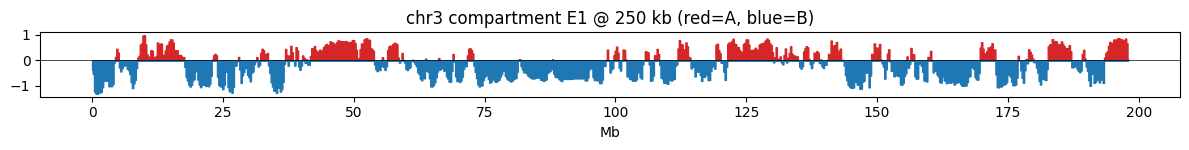

In [7]:
# Save A/B as a BED file: chr  start  end  AorB  E1 (E1 is the first eigenvector, the one conventionally used for A/B compartments).  Drop bins where E1 is NaN (e.g. unmappable regions), and assign compartment labels by the sign of E1.

comp = eig_vecs[['chrom', 'start', 'end', 'E1']].copy()
comp = comp.dropna(subset=['E1'])
comp['compartment'] = np.where(comp['E1'] > 0, 'A', 'B')
comp_path = OUT / 'compartments_250kb.bed'
comp[['chrom', 'start', 'end', 'compartment', 'E1']].to_csv(
    comp_path, sep='\t', header=False, index=False)
print('wrote', comp_path, '|', len(comp), 'bins  |  A:',
      (comp.compartment == 'A').sum(), ' B:', (comp.compartment == 'B').sum())

# Quick visualisation
for chr_ in (DEMO_CHRS or comp.chrom.unique()[:1]):
    sub = comp[comp.chrom == chr_]
    plt.figure(figsize=(12, 1.6))
    plt.fill_between(sub.start / 1e6, 0, sub.E1.clip(lower=0), color='C3', step='mid')
    plt.fill_between(sub.start / 1e6, 0, sub.E1.clip(upper=0), color='C0', step='mid')
    plt.axhline(0, color='k', lw=0.5)
    plt.title(f'{chr_} compartment E1 @ {COMP_RES // 1000} kb (red=A, blue=B)')
    plt.xlabel('Mb')
    plt.tight_layout()
    plt.show()

## 2. TAD boundaries via insulation @ 25 kb

`cooltools.insulation` slides a diamond window and reports a per-bin insulation score; local minima are TAD boundaries. We pick a window size of 5×resolution = 125 kb. 3dgnome expects boundaries as a BED with `chr  pos  pos` (zero-length point intervals).

In [8]:
TAD_RES = 25_000
WINDOWS = [3 * TAD_RES, 5 * TAD_RES, 10 * TAD_RES]

clr_hic_tad = ensure_balanced(HIC_MCOOL, TAD_RES)
if DEMO_CHRS is not None:
    tad_view = view[view['chrom'].isin(DEMO_CHRS)].reset_index(drop=True)
else:
    tad_view = view

insulation = cooltools.insulation(
    clr_hic_tad,
    window_bp=WINDOWS,
    view_df=tad_view,
    ignore_diags=2,
    clr_weight_name='weight',
)

insulation.head()

INFO:root:fallback to serial implementation.


,chrom,start,end,region,is_bad_bin,log2_insulation_score_75000,n_valid_pixels_75000,log2_insulation_score_125000,n_valid_pixels_125000,log2_insulation_score_250000,n_valid_pixels_250000,boundary_strength_75000,boundary_strength_125000,boundary_strength_250000,is_boundary_75000,is_boundary_125000,is_boundary_250000
19647,chr3,0,25000,chr3_p,False,0.668523,1.0,0.583206,3.0,0.979454,8.0,NaN,NaN,NaN,False,False,False
19648,chr3,25000,50000,chr3_p,False,0.232472,3.0,0.526128,7.0,1.078666,17.0,NaN,NaN,NaN,False,False,False
19649,chr3,50000,75000,chr3_p,False,0.145881,6.0,0.525400,12.0,1.127372,27.0,NaN,NaN,NaN,False,False,False
19650,chr3,75000,100000,chr3_p,False,0.286055,6.0,0.531171,17.0,1.081656,37.0,NaN,NaN,NaN,False,False,False
19651,chr3,100000,125000,chr3_p,False,0.413812,6.0,0.516668,22.0,1.144747,47.0,NaN,0.057097,NaN,False,False,False


In [9]:
# Pick the middle window as the canonical boundary set
win = WINDOWS[1]
is_boundary_col = f'is_boundary_{win}'
boundary_strength_col = f'boundary_strength_{win}'

boundaries = insulation[insulation[is_boundary_col]].copy()

# Keep only strong boundaries (top 80% by strength is a reasonable threshold)
thr = boundaries[boundary_strength_col].quantile(0.2)
boundaries = boundaries[boundaries[boundary_strength_col] >= thr]

# Midpoint of each boundary bin to 3dgnome breakpoint (zero-length BED interval)
boundaries['pos'] = ((boundaries['start'] + boundaries['end']) // 2).astype(int)
bp_df = boundaries[['chrom', 'pos']].copy()
bp_df['end'] = bp_df['pos']
bp_path = OUT / 'tad_breakpoints.bed'
bp_df[['chrom', 'pos', 'end']].to_csv(bp_path, sep='\t', header=False, index=False)
print('wrote', bp_path, '|', len(bp_df), 'TAD breakpoints (strong only)')

wrote /Users/nk2/Desktop/3dgnome-torch/playground/derived/tad_breakpoints.bed | 329 TAD breakpoints (strong only)


## 3. Loop calling with `cooltools.dots`

`cooltools.dots` is the Python-native HiCCUPS implementation. It tests every pixel for local enrichment over a distance-dependent expected, using HiCCUPS' donut / lower-left / etc. kernels.
ChIA-PET ICE-balance weights mask out most low-coverage bins, so we inject a unit-weight column (`raw` = 1.0) into the .mcool and run the detector on that, effectively HiCCUPS on raw PET counts.

In [11]:
import h5py

LOOP_RES = 10_000
chia_cool = f'{CHIAPET_MCOOL}::resolutions/{LOOP_RES}'

# Inject a unit-weight column so cooltools sees raw PET counts. The ChIA-PET ICE 'weight' column NaNs out most bins, which makes HiCCUPS blank.
# cooltools accepts `clr_weight_name='raw'` to read this column.

with h5py.File(CHIAPET_MCOOL, 'r+') as h5:
    grp = h5[f'resolutions/{LOOP_RES}/bins']
    if 'raw' not in grp:
        n = grp['chrom'].shape[0]
        grp.create_dataset('raw', data=np.ones(n, dtype=np.float64))
        print(f'injected unit weights ({n} bins)')
    else:
        print('unit weights already present')

clr_chia = cooler.Cooler(chia_cool)
print('bin columns:', clr_chia.bins().columns.tolist())

unit weights already present
bin columns: ['chrom', 'start', 'end', 'raw']


In [12]:
# Build a single-chrom view for the demo (full-genome works the same way).
loop_view = bioframe.make_viewframe([
    (chrom, 0, clr_chia.chromsizes[chrom], chrom)
    for chrom in (DEMO_CHRS or clr_chia.chromnames)
])

# Distance-dependent expected (cis), on raw counts via the 'raw' weight col.
expected = cooltools.expected_cis(
    clr=clr_chia,
    view_df=loop_view,
    nproc=os.cpu_count() or 4,
    clr_weight_name='raw',
    ignore_diags=2,
)
expected.head()

INFO:root:creating a Pool of 12 workers
/opt/anaconda3/envs/3dgnome-bio/lib/python3.11/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg
0,chr3,chr3,0,0,NaN,19830,19830,NaN,NaN,NaN,NaN,NaN,NaN
1,chr3,chr3,1,10000,0.105523,19829,19829,NaN,NaN,NaN,NaN,0.105523,0.105523
2,chr3,chr3,2,20000,9.212304,19828,19828,196230.0,196230.0,9.896611,9.896611,9.212304,9.212304
3,chr3,chr3,3,30000,6.543884,19827,19827,132175.0,132175.0,6.666414,6.666414,6.543884,6.543884
4,chr3,chr3,4,40000,5.105401,19826,19826,103233.0,103233.0,5.206950,5.206950,5.105401,5.105401


In [13]:
dots = cooltools.dots(
    clr=clr_chia,
    expected=expected,
    view_df=loop_view,
    max_loci_separation=2_000_000,
    max_nans_tolerated=10,
    lambda_bin_fdr=0.5,
    clr_weight_name='raw',
    clustering_radius=20_000,
    nproc=os.cpu_count() or 4,
)
print(dots.shape, 'dot calls')
dots.head()

INFO:root:Using recommended donut-based kernels with w=5, p=2 for binsize=10000
INFO:root:creating a Pool of 12 workers
INFO:root:convolving 79 tiles to build histograms for lambda-bins
INFO:root:Done building histograms in 2.344 sec ...
/opt/anaconda3/envs/3dgnome-bio/lib/python3.11/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/opt/anaconda3/envs/3dgnome-bio/lib/python3.11/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
INFO:root:Determined thresholds for every lambda-bin ...
INFO:root:creating a Pool of 12 workers
INFO:root:convolving 79 tiles to extract enriched pixel

(6432, 22) dot calls


,chrom1,start1,end1,chrom2,start2,end2,count,la_exp.donut.value,la_exp.vertical.value,la_exp.horizontal.value,...,la_exp.vertical.qval,la_exp.horizontal.qval,la_exp.lowleft.qval,region,cstart1,cstart2,c_label,c_size,region1,region2
0,chr3,50000,60000,chr3,350000,360000,54,3.729904,10.598556,6.228018,...,9.159289e-17,2.495510e-30,4.622480e-50,chr3,53333.333333,356666.666667,0,3,chr3,chr3
1,chr3,140000,150000,chr3,350000,360000,38,2.864358,12.974606,2.627090,...,1.821780e-05,3.222006e-26,2.154231e-26,chr3,136000.000000,350000.000000,2,5,chr3,chr3
2,chr3,120000,130000,chr3,270000,280000,10,2.902448,3.830071,3.290625,...,4.569156e-02,4.607945e-02,1.045313e-02,chr3,123333.333333,266666.666667,3,3,chr3,chr3
3,chr3,140000,150000,chr3,430000,440000,3,1.267417,1.047296,1.102417,...,3.311975e-01,3.229345e-01,4.611707e-01,chr3,145000.000000,440000.000000,4,2,chr3,chr3
4,chr3,200000,210000,chr3,350000,360000,69,2.812449,11.004712,4.153739,...,5.040282e-27,3.217262e-51,9.117752e-71,chr3,191666.666667,353333.333333,6,6,chr3,chr3


In [14]:
# cooltools.dots stores the raw observed count in a column literally named 'count'.
loops = dots.rename(columns={'count': 'pet_count'}).copy()

if DEMO_CHRS is not None:
    loops = loops[loops.chrom1.isin(DEMO_CHRS) & loops.chrom2.isin(DEMO_CHRS)].copy()

loops = loops[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'pet_count']]
loops['pet_count'] = loops['pet_count'].astype(int)
print(loops.shape, 'loops with PET counts')
loops.head()

(6432, 7) loops with PET counts


,chrom1,start1,end1,chrom2,start2,end2,pet_count
0,chr3,50000,60000,chr3,350000,360000,54
1,chr3,140000,150000,chr3,350000,360000,38
2,chr3,120000,130000,chr3,270000,280000,10
3,chr3,140000,150000,chr3,430000,440000,3
4,chr3,200000,210000,chr3,350000,360000,69


## 4. CTCF motif filter (JASPAR MA0139.1, hg38)

Download the pre-scanned JASPAR motif track for CTCF on hg38, intersect each loop anchor with it, drop loops without CTCF support on both anchors, and record the dominant motif orientation per anchor (R = + strand, L = – strand),  this is the format `3dgnome` expects in `anchors_*_oriented.bed`.

In [15]:
# Pre-scanned JASPAR 2022 CTCF predictions for hg38, FIMO-style.
ctcf_url = 'http://expdata.cmmt.ubc.ca/JASPAR/downloads/UCSC_tracks/2022/hg38/MA0139.1.tsv.gz'
ctcf_cache = CWD / 'jaspar_MA0139.1_hg38.tsv.gz'
if not ctcf_cache.exists():
    print(f'Downloading {ctcf_url}')
    with requests.get(ctcf_url, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0)) or None
        with open(ctcf_cache, 'wb') as fh, tqdm(
            total=total, unit='B', unit_scale=True, unit_divisor=1024,
            desc='MA0139.1.tsv.gz') as bar:
            for chunk in r.iter_content(chunk_size=2 ** 20):
                fh.write(chunk)
                bar.update(len(chunk))

# Format: chrom  start  end  name  rel_score  fimo_score  strand
ctcf = pd.read_csv(
    ctcf_cache, sep='\t', comment='#',
    names=['chrom', 'start', 'end', 'name', 'rel_score', 'fimo_score', 'strand'],
)

if DEMO_CHRS is not None:
    ctcf = ctcf[ctcf.chrom.isin(DEMO_CHRS)].copy()

# rel_score is the JASPAR relative score on the 0..1000 scale (1000 = best PWM match).
# 400 keeps reasonably well-matched CTCF sites without being overly strict.
ctcf = ctcf[ctcf.rel_score >= 400].reset_index(drop=True)
print(ctcf.shape, 'CTCF motif sites kept')
print('rel_score quantiles:', ctcf.rel_score.quantile([0.5, 0.9, 0.99]).to_dict())
ctcf

(45242, 7) CTCF motif sites kept
rel_score quantiles: {0.5: 816.0, 0.9: 855.0, 0.99: 912.0}


,chrom,start,end,name,rel_score,fimo_score,strand
0,chr3,14216,14235,CTCF,839,459,-
1,chr3,15843,15862,CTCF,833,448,-
2,chr3,18988,19007,CTCF,820,423,-
3,chr3,25580,25599,CTCF,815,412,+
4,chr3,33165,33184,CTCF,815,412,+
...,...,...,...,...,...,...,...
45237,chr3,198224581,198224600,CTCF,810,403,+
45238,chr3,198224584,198224603,CTCF,870,528,+
45239,chr3,198224850,198224869,CTCF,846,475,+
45240,chr3,198225695,198225714,CTCF,843,468,-


In [16]:
# Overlap each loop anchor with CTCF motif sites; pick the top-scoring (rel_score) motif per anchor as the orientation source.
# Note: we no longer drop loops without CTCF here, that filter is applied only to the 3+ cluster bucket downstream, so the singletons file matches the  original 3dgnome convention (no CTCF requirement, no orientation column).

def annotate_anchor_orientation(anchors: pd.DataFrame, motifs: pd.DataFrame) -> pd.DataFrame:
    out = bioframe.overlap(anchors, motifs, how='left', suffixes=('', '_motif'), return_index=True)
    out['rel_score_motif'] = pd.to_numeric(out['rel_score_motif'], errors='coerce')
    out = (out.sort_values('rel_score_motif', ascending=False).drop_duplicates(subset=['chrom', 'start', 'end']))
    out['orient'] = np.where(out['strand_motif'] == '-', 'L', np.where(out['strand_motif'] == '+', 'R', None))
    return out[['chrom', 'start', 'end', 'orient', 'rel_score_motif']]


a1 = loops[['chrom1', 'start1', 'end1']].rename(columns={'chrom1': 'chrom', 'start1': 'start', 'end1': 'end'})
a2 = loops[['chrom2', 'start2', 'end2']].rename( columns={'chrom2': 'chrom', 'start2': 'start', 'end2': 'end'})

a1_o = annotate_anchor_orientation(a1, ctcf).set_index(['chrom', 'start', 'end'])
a2_o = annotate_anchor_orientation(a2, ctcf).set_index(['chrom', 'start', 'end'])

loops['orient1'] = loops.set_index(['chrom1', 'start1', 'end1']).index.map(a1_o['orient'])
loops['orient2'] = loops.set_index(['chrom2', 'start2', 'end2']).index.map(a2_o['orient'])

n_total = len(loops)
n_both_ctcf = loops[['orient1', 'orient2']].notna().all(axis=1).sum()
n_ge3 = (loops.pet_count >= 3).sum()
n_ge3_ctcf = ((loops.pet_count >= 3) & loops[['orient1', 'orient2']].notna().all(axis=1)).sum()
print(f'total loops: {n_total}')
print(f'  both anchors have CTCF: {n_both_ctcf}')
print(f'  pet_count >= 3: {n_ge3}')
print(f'  pet_count >= 3 AND CTCF: {n_ge3_ctcf} <- becomes clusters_3+')

total loops: 6432
  both anchors have CTCF: 5623
  pet_count >= 3: 6432
  pet_count >= 3 AND CTCF: 5623 <- becomes clusters_3+


## 5. Split into `clusters_3+.bedpe` and `singletons_lessthan3.bedpe`

Following the file format the `[data]` section of `config.ini` expects:
* `GM12878_clusters_3+.bedpe`,  anchor pairs with `pet_count >= 3` (`chr s e chr s e count`)
* `GM12878_clusters_3+_oriented.bedpe`,  same + two orientation columns `chr s e chr s e L|R L|R count`
* `GM12878_anchors_3+_oriented.bed`,  deduplicated union of anchors from the 3+ set, with their CTCF orientation
* `GM12878_singletons_lessthan3.bedpe`,  pairs with `pet_count < 3` (same 7-column format, no orientation)

In [76]:
PET_THRESHOLD = 3

# Clusters: pet_count >= 3 AND both anchors carry a CTCF motif.
# Singletons: pet_count < 3, no CTCF requirement.
both_ctcf = loops[['orient1', 'orient2']].notna().all(axis=1)
clusters = loops[(loops.pet_count >= PET_THRESHOLD) & both_ctcf].copy()
singletons = loops[loops.pet_count < PET_THRESHOLD].copy()
print(
    f'clusters (>={PET_THRESHOLD} + CTCF) : {len(clusters)}   '
    f'singletons (<{PET_THRESHOLD}) : {len(singletons)}'
)

# Unoriented clusters
clusters_bedpe = clusters[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'pet_count']]
clusters_bedpe.to_csv(OUT / 'GM12878_clusters_3+.bedpe', sep='\t', header=False, index=False)

# Oriented clusters (same but with orient1 and orient2 columns)
clusters_or = clusters[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'orient1', 'orient2', 'pet_count']]
clusters_or.to_csv(OUT / 'GM12878_clusters_3+_oriented.bedpe', sep='\t', header=False, index=False)

# Singletons
singletons_bedpe = singletons[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'pet_count']]
singletons_bedpe.to_csv(OUT / 'GM12878_singletons_lessthan3.bedpe', sep='\t', header=False, index=False)

# Anchors BED (unique anchors from the cluster set, with orientation)
anchors_left = (
    clusters[['chrom1', 'start1', 'end1', 'orient1']]
    .rename(columns={'chrom1': 'chrom', 'start1': 'start', 'end1': 'end', 'orient1': 'orient'})
)
anchors_right = (
    clusters[['chrom2', 'start2', 'end2', 'orient2']]
    .rename(columns={'chrom2': 'chrom', 'start2': 'start', 'end2': 'end', 'orient2': 'orient'})
)
anchors = (
    pd
    .concat([anchors_left, anchors_right], ignore_index=True)
    .drop_duplicates()
    .sort_values(['chrom', 'start', 'end'])
    .reset_index(drop=True)
)

anchors.to_csv(OUT / 'GM12878_anchors_3+_oriented.bed', sep='\t', header=False, index=False)
anchors[['chrom', 'start', 'end']].to_csv(OUT / 'GM12878_anchors_3+.bed', sep='\t', header=False, index=False)

print('Wrote:')
for fp in sorted(OUT.glob('GM12878_*')):
    print(fp.name, '(', fp.stat().st_size, 'bytes)')

clusters (>=3 + CTCF) : 5623   singletons (<3) : 0
Wrote:
GM12878_anchors_3+.bed ( 101995 bytes)
GM12878_anchors_3+_oriented.bed ( 110525 bytes)
GM12878_clusters_3+.bedpe ( 284015 bytes)
GM12878_clusters_3+_oriented.bedpe ( 306507 bytes)
GM12878_singletons_lessthan3.bedpe ( 0 bytes)


## 6. Run 3dgnome on a region using the derived files

We make a small config that points `[data]` to the freshly generated files and the TAD breakpoints, then call the existing pipeline entrypoint.

In [17]:
# Centromeres BED is already in data/GM12878,  reuse it.
shutil.copy(CWD / 'hg38_centromeres.bed', OUT / 'hg38_centromeres.bed')

cfg_src = CWD / 'config_sample.ini'
cfg_dst = OUT / 'config.ini'

import configparser

cfg = configparser.ConfigParser(inline_comment_prefixes=('#', ';'))
cfg.read(cfg_src)
cfg['data']['data_dir'] = str(OUT)
cfg['data']['anchors'] = 'GM12878_anchors_3+_oriented.bed'
cfg['data']['clusters'] = 'GM12878_clusters_3+.bedpe'
cfg['data']['singletons'] = 'GM12878_singletons_lessthan3.bedpe'
cfg['data']['singletons_inter'] = 'mock.txt'
cfg['data']['segment_split'] = 'tad_breakpoints.bed'
cfg['data']['centromeres'] = 'hg38_centromeres.bed'
with open(cfg_dst, 'w') as fh:
    cfg.write(fh)
print('wrote', cfg_dst)

wrote /Users/nk2/Desktop/3dgnome-torch/playground/derived/config.ini


In [18]:
from gnome3d.simulate import run_region

# Pick a region inside the demo chromosome,  first 20 Mb of chr3 is small
# enough to finish in a few minutes on a laptop.
region = f'{DEMO_CHRS[0]}:1000000-2000000' if DEMO_CHRS else 'chr3:1000000-2000000'

structures = run_region(
    config_path=str(cfg_dst),
    data_dir=str(OUT),
    region=region,
    n_structures=1,
)
structure = structures[0]
print(f'{len(structure)} beads produced for {region}')

[data] load anchors
  anchors loaded: chr3: 9
[data] load arcs
  arcs loaded: 3, long arcs separated: 0
[data] mark arcs
  marked arcs chr3: 3
[data] remove empty anchors
  removed empty anchors chr3: 4
[data] load breakpoints
[data] load singletons
  singletons loaded: 0
[solver] build cluster hierarchy
  total clusters: 8

[simulate] structure 1/1
[solver] single segment -> place at origin

[solver] anchor level: chr3

[solver] chr3 IB 1/1  (5 anchors)
  chr3 IB 1/1 run 1/1
    [chr3 IB 1/1 run 1/1] step  50,000  score=3.6123  ratio=0.0030  ok=5453/50000
    [chr3 IB 1/1 run 1/1] step 100,000  score=3.6123  ratio=1.0000  ok=13/50000  [done]
  chr3 IB 1/1 smooth 1/1
    [chr3 IB 1/1 smooth 1/1] step  50,000  score=84.8575  ratio=0.0498  ok=4318/50000
    [chr3 IB 1/1 smooth 1/1] step 100,000  score=47.9748  ratio=0.5654  ok=231/50000
    [chr3 IB 1/1 smooth 1/1] step 150,000  score=37.6811  ratio=0.7854  ok=122/50000
    [chr3 IB 1/1 smooth 1/1] step 200,000  score=30.7666  ratio=0.81

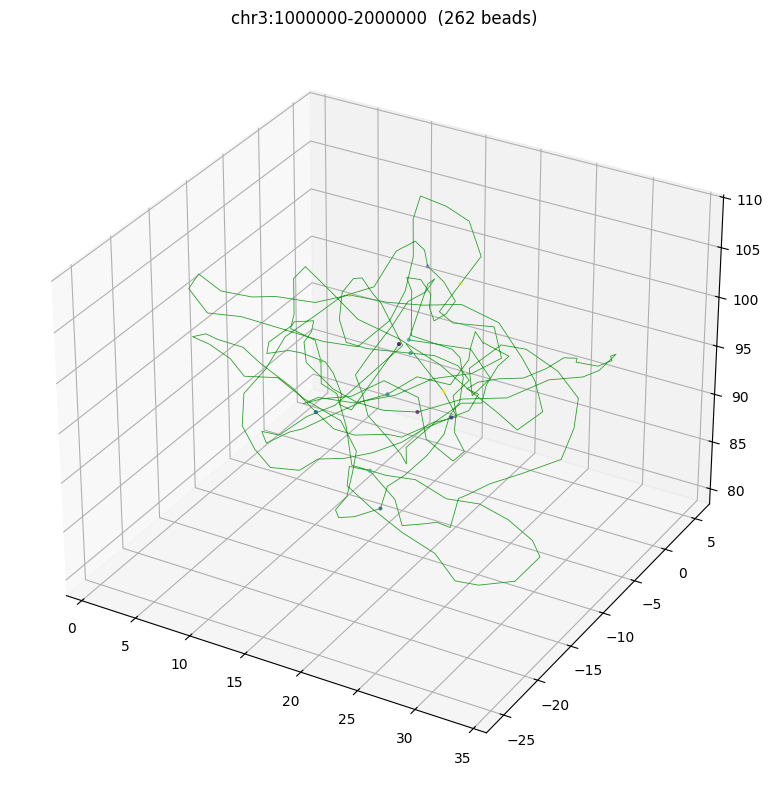

In [19]:
# Visualise the structure (axis-equal projection).
xs = [b.x for b in structure]
ys = [b.y for b in structure]
zs = [b.z for b in structure]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, ys, zs, lw=0.6, color='C2')
ax.scatter(xs[::20], ys[::20], zs[::20], s=4, c=np.arange(len(xs))[::20], cmap='viridis')
ax.set_title(f'{region}  ({len(structure)} beads)')
plt.tight_layout();
plt.show()

In [20]:
# Write cif
from gnome3d.io import write_cif

cif_path = OUT / f'{DEMO_CHRS[0]}_structure.cif' if DEMO_CHRS else OUT / 'chr3_structure.cif'
write_cif(cif_path, structure)
print('wrote', cif_path, '  (', cif_path.stat().st_size, 'bytes)')

wrote /Users/nk2/Desktop/3dgnome-torch/playground/derived/chr3_structure.cif   ( 33135 bytes)
